# Chapter 12: The Competition
A small synthetic panel provides repeated rolling origins and a common test for
naive, seasonal-naive, trend and combination forecasts. This is not an M-series
competition reproduction. No algorithm is required to win for the notebook to pass.

In [1]:
from pathlib import Path
import sys
project=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'companion/src').exists())
sys.path.insert(0,str(project/'companion/src'))
from forecasting_companion.common import *
rng=begin(12); series=np.array([seasonal_series(rng)+rng.normal(0,4,144) for _ in range(30)])
names=['Naive','Seasonal naive','Drift','Ensemble']; errors=np.zeros((30,4,5,12))

## The origin defines what is knowable
Every model receives only values before its origin. The ensemble has fixed equal
weights; the held-out errors are not used to choose weights.

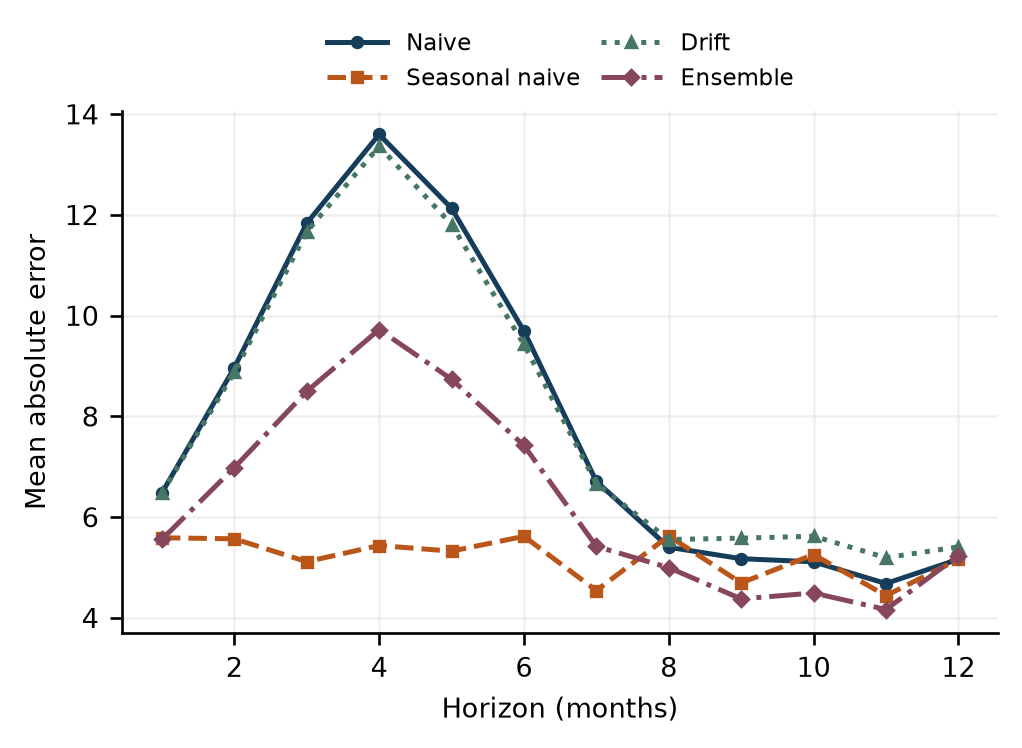

In [2]:
for j,y in enumerate(series):
    for k,origin in enumerate([72,84,96,108,120]):
        train=y[:origin]; truth=y[origin:origin+12]
        preds=[np.repeat(train[-1],12),train[-12:],train[-1]+np.arange(1,13)*(train[-1]-train[0])/(len(train)-1)]
        preds.append(np.mean(preds,axis=0))
        for m,pred in enumerate(preds): errors[j,m,k]=abs(truth-pred)
plt.figure()
for name,err in zip(names,errors.mean(axis=(0,2))): plt.plot(range(1,13),err,label=name)
plt.xlabel('Horizon (months)'); plt.ylabel('Mean absolute error'); plt.legend(fontsize=7)
save(12,1,'Compare the same forecast horizons','Thirty synthetic monthly series and five rolling origins. Every method is evaluated against the same future observations.','## Section Three: The Problem of Measuring Accuracy')

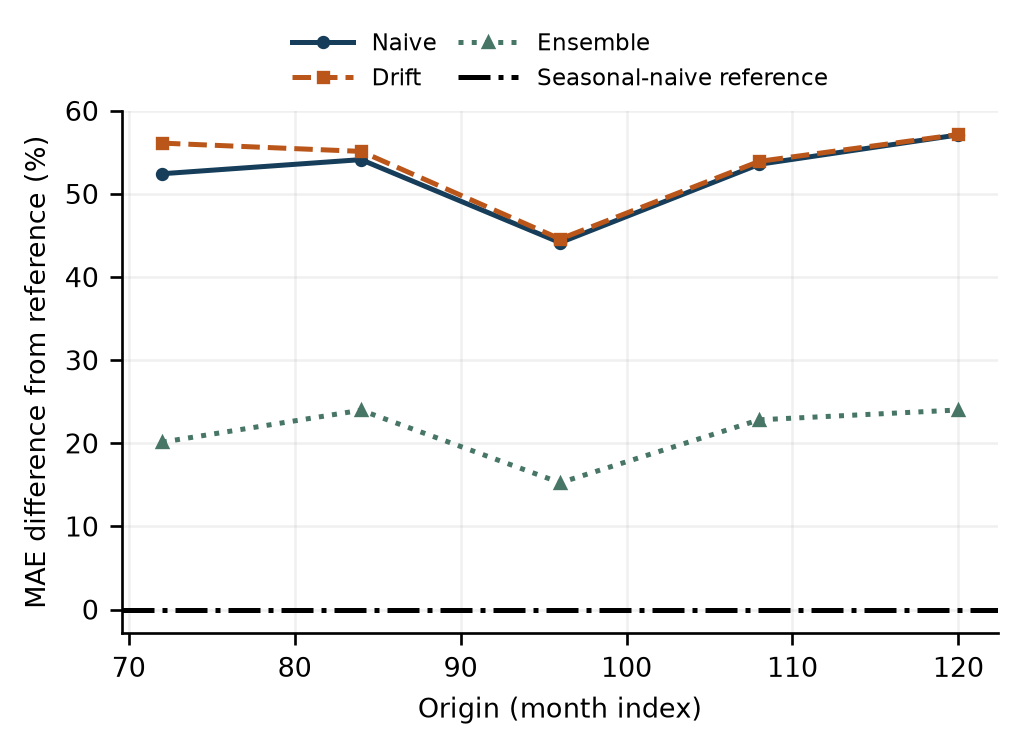

In [3]:
origin_errors=errors.mean(axis=(0,3))
relative_errors=100*(origin_errors/origin_errors[1]-1)
plt.figure()
for i,name in enumerate(names):
    if i != 1: plt.plot([72,84,96,108,120],relative_errors[i],'o-',label=name)
plt.axhline(0,color='black',ls='--',label='Seasonal-naive reference')
plt.xlabel('Origin (month index)'); plt.ylabel('MAE difference from reference (%)'); plt.legend(fontsize=6)
save(12,2,'How large is the gap to the benchmark?','At each origin, average errors cover the same thirty synthetic series and twelve horizons. Values are 100 × (method MAE / seasonal-naive MAE − 1); zero ties the benchmark and negative is better. Stable ranks can still hide changing error gaps.','## Section Four: A Systematic Account of What the Competitions Established')

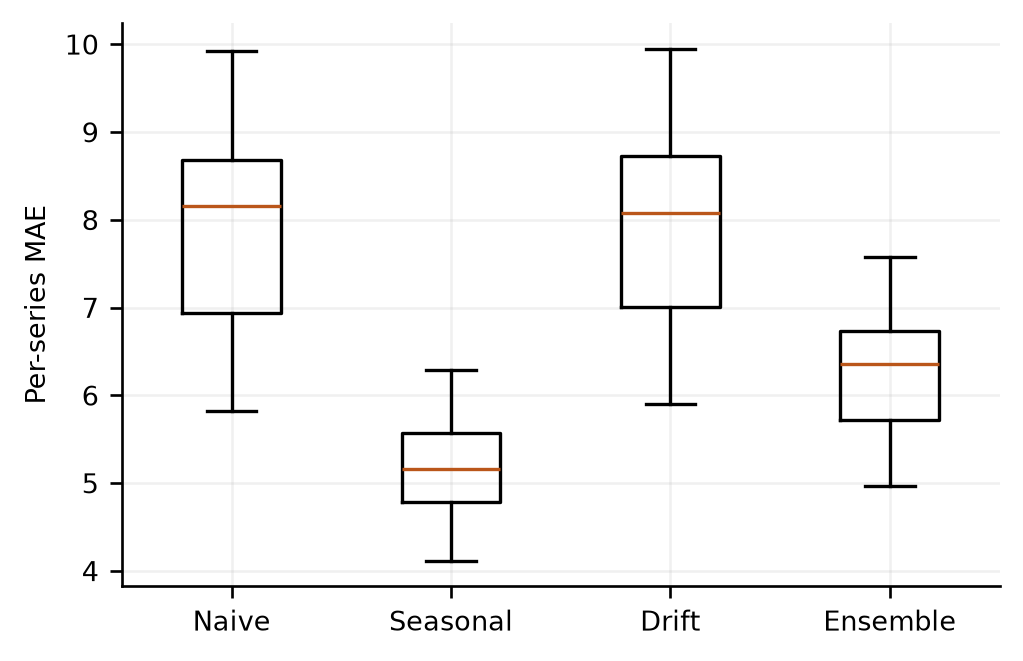

{'Naive': np.float64(7.91231352630697), 'Seasonal naive': np.float64(5.197539318876307), 'Drift': np.float64(7.969889549635048), 'Ensemble': np.float64(6.3005252212651905)}


In [4]:
plt.figure(); plt.boxplot(list(errors.mean(axis=(2,3)).T),tick_labels=['Naive','Seasonal','Drift','Ensemble']); plt.ylabel('Per-series MAE')
save(12,3,'Combination is a candidate, not a guarantee','Per-series mean errors across the same rolling origins. Equal-weight combinations can be robust without beating every constituent.','## Section Five: What This Means for Your Organization')
assert np.isfinite(errors).all()
print(dict(zip(names,errors.mean(axis=(0,2,3)))))

## RMSE and MASE answer different questions
Squaring errors emphasizes large misses. MASE instead divides each held-out
absolute error by that series' training seasonal-naive scale, recomputed inside
every origin. Never estimate the scale from future observations. Constant
seasonal histories have undefined MASE and would be reported rather than hidden.

In [5]:
scales = np.empty((len(series), 5))
for j, values in enumerate(series):
    for k, origin in enumerate([72,84,96,108,120]):
        training = values[:origin]
        scales[j,k] = np.mean(np.abs(training[12:]-training[:-12]))
assert np.all(scales > 0), 'This fixture requires positive seasonal scaling errors.'
scaled_errors = errors/scales[:,None,:,None]
metrics = {name: {'MAE': float(errors[:,i].mean()),
                  'RMSE': float(np.sqrt(np.mean(errors[:,i]**2))),
                  'seasonal_MASE': float(scaled_errors[:,i].mean())}
           for i, name in enumerate(names)}
print(metrics)
assert all(row['RMSE'] >= row['MAE']-1e-12 for row in metrics.values())

{'Naive': {'MAE': 7.912313526306969, 'RMSE': 9.825837520103041, 'seasonal_MASE': 1.5746563640442066}, 'Seasonal naive': {'MAE': 5.197539318876307, 'RMSE': 6.47430692599266, 'seasonal_MASE': 1.0336739779943471}, 'Drift': {'MAE': 7.969889549635047, 'RMSE': 9.862680096719352, 'seasonal_MASE': 1.5854261339694076}, 'Ensemble': {'MAE': 6.300525221265192, 'RMSE': 7.817554100037038, 'seasonal_MASE': 1.2533041656681396}}


## Limits and exercise
MASE divides by an in-sample naive error scale, so MASE=1 does not mean tied with
the held-out naive forecast. Try series without seasonality or with level breaks.
Formal model confidence sets and dependence-aware significance tests need a
larger, appropriately structured evaluation than a single convenient panel.

<!-- APPLIED-WORKSHOP-START -->
## Guided application workshop
The sections below connect the controlled figures to a complete applied input/output workflow.

# Chapter 12 workshop: from lesson to decision

## Explain the mechanism

A benchmark is an experimental design. Common target dates, equal information and frozen selection rules matter as much as the error formula. An ensemble is a candidate; averaging is not a guarantee of improvement.

## Work through the arithmetic

Actuals [10,20] with forecasts [12,16] give errors [2,4], MAE=3 and RMSE=sqrt(10)=3.162. If the training seasonal-naive scale is 2, MASE=1.5. That 1.5 does not compare directly with a held-out naive forecast unless its actual held-out loss is separately calculated.

Treat this hand calculation as a mechanism check. Compare its units and assumptions with the business target before using the executable adapter below.

## Adapt the lesson to reader data

Replace the generated panel with sorted grouped series. Recompute each scale inside its training window. Keep the lesson’s per-horizon error array structure or an equivalent long table; averaging too early hides cases and makes fair alignment hard to audit.

Keep the controlled example as a reproducible teaching case. Work in a copy when replacing its data; retain raw input, a cleaned table and an explanation of exclusions. Real data need a named source, extraction date, usable-as-of date and units. If an actual is revised later, preserve the vintage available when the forecast would have been issued. Never silently label synthetic generator output as an external dataset.

For this chapter, settle these questions before fitting: What horizon and loss match the decision? Which series and origins define deployment? Are weights business volume weights or equal-series weights? Is there an untouched final test?

## Interpret the actual lesson outputs

The relative-error chart uses 100×(method MAE/seasonal-naive MAE-1), so negative is better and zero ties that origin’s baseline. The boxplot shows per-series heterogeneity. These synthetic seasonal series are not an M-competition reproduction.

The current applied adapter adds a separately inspectable numerical result:

- `results.csv`: `timestamp,forecast,model (plus series_id for a panel)`.
- `summary.json`: inspect `selected,validation,validation_predictions,test_mae,intervals; per-series summaries for a panel`.

Each series independently runs the companion engine with the `full` pool: the chapter 4 smoothing family with an AICc-selected ETS form, Theta, STL+ETS, the chapter 6 ARIMA family with diagnostic differencing, LightGBM on lags when history allows, a median of the top three, an equal ensemble, and the naive, seasonal-naive and drift benchmarks. Validation includes MAE, RMSE and training-scaled MASE at up to five origins plus a final untouched holdout; interval coverage is measured for every model that produces intervals. No pooled business-weight ranking or formal significance test is produced. Short valid histories return a provisional naive baseline and optional seasonal-naive scenario; these are not validated model comparisons.

The [fixture](../data/examples/ch12.csv) and [config](../configs/ch12.json) match the current interface. Run the `apply` command in the [skill entrypoint](../../forecasting-skills/forecasting-ch12-benchmarking/SKILL.md), using a new empty output folder. Any broader methodology in this workshop requires separately recorded evidence or an explicit extension; successful command execution does not imply those steps happened.

## Decide what the evidence supports

MAE is unit-dependent; RMSE emphasizes large misses. Seasonal MASE divides by training seasonal-naive absolute differences, not held-out naive error. Zero scale makes MASE undefined. Overlapping origins and related series weaken naive significance calculations.

If histories differ, report the common eligible evaluation subset and separately report deployment coverage. If MASE scale is zero, flag it and use an unscaled metric rather than adding an arbitrary epsilon. With few origins, report descriptive results without broad superiority claims.

The applied deliverable must make these items inspectable: Return prediction-level records, per-series/per-origin/per-horizon losses, weighting rules, coverage and failed-fit counts, baseline comparisons and final-selection separation.

## Three exercises with worked solutions

### Exercise 1

Method MAE=8, baseline MAE=10: relative gap?

**Worked solution.** 100×(8/10-1)=-20%, a 20% lower MAE on those matched cases.

### Exercise 2

Training seasonal-naive error scale is zero. What is MASE?

**Worked solution.** Undefined, not zero. Flag it and report an appropriate unscaled metric.

### Exercise 3

Weights are tuned using the final test. Is it still a final test?

**Worked solution.** No. It became selection data; evaluate the frozen combination on later untouched cases.

## Business-reader application

Use this request with the skill:

> Use chapter 12 to build a common rolling-origin benchmark for panel.csv, retain prediction-level records and compare methods under explicit business weights.

Read the returned result as a decision record. Check that the forecast answers your unit and horizon, that its comparison uses information available at the time, and that any recommendation follows from the stated loss or business objective. Ask which missing measurement would most change the conclusion.

## Observed-data transfer exercise

A bundled [observed series](../data/observed/monthly-temperature.csv) and [matching config](../configs/ch12-observed.json) provide a second application after the controlled fixture. Read the [data registry](../data/registry.json) for provenance and transformations. These are historical snapshots, not archived real-time release vintages.

```bash
companion/.venv/bin/python companion/scripts/run.py apply --chapter 12 \
  --input companion/data/observed/monthly-temperature.csv \
  --config companion/configs/ch12-observed.json \
  --output companion/applied-runs/ch12-observed-reader
```

Explain why a ranking on this one observed series does not establish an across-industry ranking. Record the actual result of your run. Do not import the controlled example’s winner or interpret a successful numerical execution as evidence of operational accuracy.

## Configure and run the applied case

The input file and JSON below are the only entry-point changes needed to try another
case with the same schema. Keep the original examples for comparison. Supply source
and units in the configuration; resolve missing periods rather than silently filling
unknown observations with zeros. These calculations call the same tested functions
as the `run.py apply` command. A failed validation is a reason to inspect the data,
not to replace it with invented observations.

The default input here is a **seeded synthetic schema example**, separate from any
observed-data application below. Read the summary before interpreting its results.

In [6]:
from forecasting_companion.applied.methods import analyze as analyze_chapter
from forecasting_companion.applied.core import clean_json
import pandas as pd
import json, os
INPUT_PATH = project_path = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'companion/src').exists()) / 'companion/data/examples/ch12.csv'
CONFIG_PATH = project_path.parents[2] / 'configs/ch12.json'
# Input paths are explicit and may be replaced with reader-supplied files.
workshop_config = json.loads(CONFIG_PATH.read_text())
workshop_input = pd.read_csv(INPUT_PATH)
workshop_table, workshop_summary = analyze_chapter(12, workshop_input, workshop_config)
print(json.dumps(clean_json(workshop_summary), indent=2))
print(workshop_table.head(12).to_string(index=False))
workshop_output = Path(os.environ.get('FORECAST_OUTPUT', CONFIG_PATH.parents[1])) / 'results'
workshop_output.mkdir(parents=True, exist_ok=True)
workshop_table.to_csv(workshop_output/'ch12-workshop-results.csv', index=False)
(workshop_output/'ch12-workshop-summary.json').write_text(json.dumps(clean_json(workshop_summary), indent=2)+'\n')

{
  "method": "Rolling-origin model comparison with final holdout",
  "pool": "full",
  "selected": "Combination(top3)",
  "transform": "none",
  "specification": {
    "ets": {
      "error": "add",
      "trend": "add",
      "damped": false,
      "seasonal": "add"
    },
    "arima": [
      [
        1,
        0,
        1
      ],
      [
        1,
        1,
        1,
        12
      ]
    ],
    "notes": {
      "transform": {
        "boxcox_lambda": 0.5388623113671784
      },
      "differencing": {
        "seasonal_strength": 0.8950633488348618,
        "kpss_d": 0,
        "seasonal_D": 1
      }
    }
  },
  "origins": [
    "2015-12-01 00:00:00+00:00",
    "2016-12-01 00:00:00+00:00",
    "2017-12-01 00:00:00+00:00",
    "2018-12-01 00:00:00+00:00",
    "2019-12-01 00:00:00+00:00"
  ],
  "horizon": 12,
  "season": 12,
  "leaderboard": [
    {
      "model": "Combination(top3)",
      "mae": 1.666520128306486,
      "rmse": 2.1071375345625567,
      "mase": 0.6521555

242460

## Apply the same workflow to observed data

This second case uses a bundled public-domain historical dataset documented in
`data/registry.json`. It is a revised snapshot, not an archived real-time vintage.
The earlier time cuts prevent fitting on held-out outcomes; they do not undo
revisions that may have occurred before the snapshot was published. Compare the
actual output below with the controlled case. A method need not win to be useful.
The source, transformation and units are in the configuration and registry.

In [7]:
observed_input = pd.read_csv(CONFIG_PATH.parents[1]/'data/observed/monthly-temperature.csv')
observed_config = json.loads((CONFIG_PATH.parent/'ch12-observed.json').read_text())
observed_table, observed_summary = analyze_chapter(12, observed_input, observed_config)
print('Observed-data source:', observed_config['source'])
print(json.dumps(clean_json(observed_summary), indent=2))
print(observed_table.head(12).to_string(index=False))
observed_table.to_csv(workshop_output/'ch12-observed-results.csv', index=False)
(workshop_output/'ch12-observed-summary.json').write_text(json.dumps(clean_json(observed_summary), indent=2)+'\n')

Observed-data source: Public-domain statsmodels El Niño observations, 1950–2010; historical revised snapshot
{
  "method": "Rolling-origin model comparison with final holdout",
  "pool": "full",
  "selected": "LightGBM",
  "transform": "log",
  "specification": {
    "ets": {
      "error": "add",
      "trend": null,
      "damped": false,
      "seasonal": "add"
    },
    "arima": [
      [
        2,
        0,
        2
      ],
      [
        0,
        1,
        1,
        12
      ]
    ],
    "notes": {
      "transform": {
        "boxcox_lambda": -0.7041897213407325
      },
      "differencing": {
        "seasonal_strength": 0.9039442193823376,
        "kpss_d": 0,
        "seasonal_D": 1
      }
    }
  },
  "origins": [
    "2004-12-01 00:00:00+00:00",
    "2005-12-01 00:00:00+00:00",
    "2006-12-01 00:00:00+00:00",
    "2007-12-01 00:00:00+00:00",
    "2008-12-01 00:00:00+00:00"
  ],
  "horizon": 12,
  "season": 12,
  "leaderboard": [
    {
      "model": "LightGBM",

232536

## Read the result as a decision record

Start with the summary’s **interpretation**, then examine its numerical evidence.
Distinguish what was fitted, what was supplied, and what remains unidentified.
The results table is the calculation; it is not permission to act. Explain which
assumption would most change the answer and what new evidence would test it.
For a live forecast, set an outcome date and keep the original result for scoring.

The exercises and worked solutions above test interpretation, calculation, and
adaptation. Re-run a changed assumption and compare the actual output; do not
reuse numbers from the book when your input or horizon changes.